Num features = 10


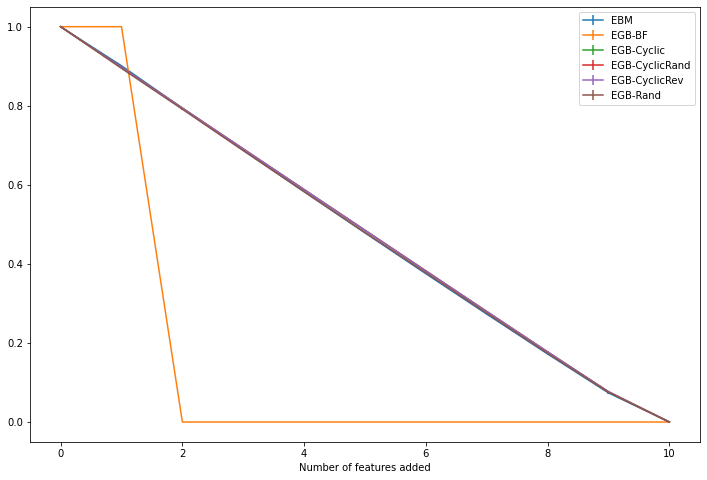

Num features = 100


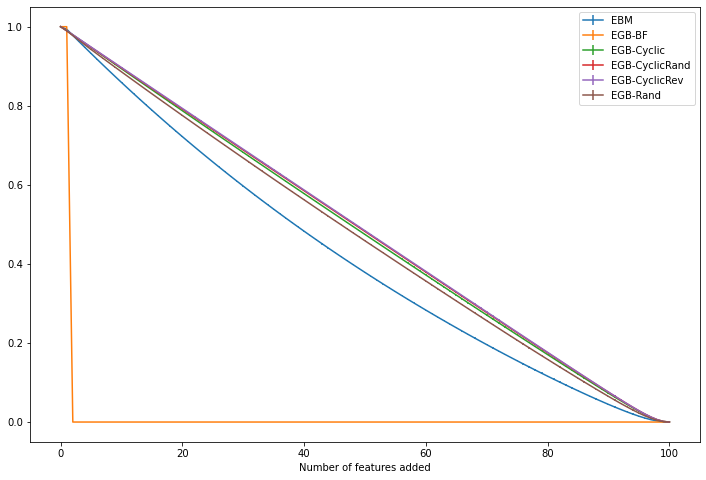

Num features = 1000


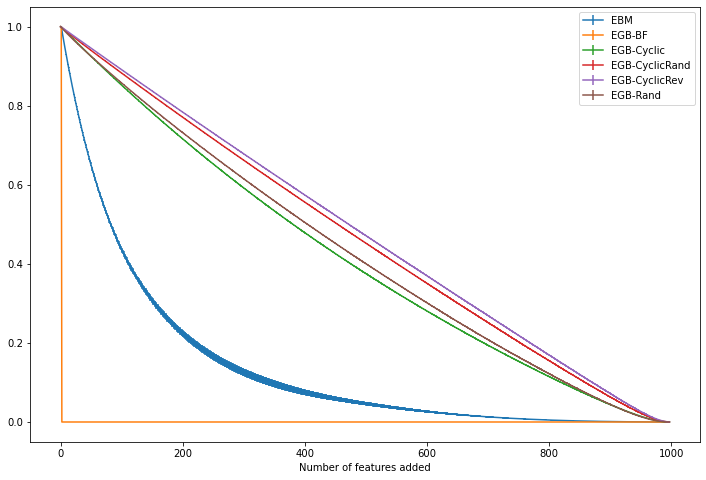

In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy  as np
import ast
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False

model_name_dict = {
        "EGB_XGB_GAM_CYCLIC_REVERSE_CYCLIC_REVERSE":"EGB-CyclicRev",
        "EGB_XGB_GAM_CYCLIC_RANDOM_CYCLIC_RANDOM":"EGB-CyclicRand",
        "EGB_XGB_GAM_CYCLIC_CYCLIC":"EGB-Cyclic",
        "EGB_XGB_GAM_RANDOM_RANDOM": "EGB-Rand",
        "EGB_XGB_GAM_BEST_FIT_BEST_FIT":"EGB-BF",
        "EBM_GAM":"EBM",
        "Spline":"Spline",
                  }

METHODS_LIST=model_name_dict.keys()

feature_sparsness_results = pd.read_csv("../feature_sparseness_results.csv")
accuracy_results = pd.read_csv("../accuracy_results.csv")
all_dfs = []
all_dfs_acc = []

for n_features in [10, 100, 1000]:
    
    dataset_name = "synthetic_ordering"+str(n_features)
    df = feature_sparsness_results[feature_sparsness_results["d_name"]==dataset_name]
    #display(df[["model_name","area_till_zero_mean"]].sort_values(by="area_till_zero_mean"))
    df = df[df["model_name"].isin(METHODS_LIST)]
    df_curr = df[["model_name","area_till_zero_mean"]].copy()
    df_curr.loc[:, "n_features"] = n_features
    all_dfs += [df_curr]
    
    df_acc = accuracy_results[accuracy_results["d_name"]==dataset_name]
    df_acc = df_acc[df_acc["model_name"].isin(METHODS_LIST)]
    df_acc = df_acc[["model_name","fit_trees_main_mean", "test_score_mean"]].copy()
    df_acc.loc[:, "n_features"] = n_features
    all_dfs_acc = [df_acc]

    df.mean_perf = df.mean_perf.apply(ast.literal_eval)
    df.std_perf = df.std_perf.apply(ast.literal_eval)

    fig, ax = plt.subplots(figsize=(12, 8))
    names_current = []
    for i, results in df.iterrows():

        name  =  model_name_dict[results["model_name"]]
        dataset_name = "Num Features = " + str(n_features)
        names_current += [name]
        the_mean = np.array(results["mean_perf"]).astype(float)
        the_std = results["std_perf"]
        ax.errorbar(range(len(the_mean)), the_mean, the_std, label=name)
    ax.legend(names_current)
    interactions = 16
    print(dataset_name.capitalize())
    #fig.suptitle(dataset_name.capitalize(), fontsize=30)#  + (" - GA^2M" if interactions>0  else " - GAM"))
    ax.set_xlabel('Number of features added')
    #ax.set_ylabel('Test RMSE')
    plt.show()

In [2]:
display(pd.concat(all_dfs).set_index(["model_name", "n_features"]).unstack().sort_values(by=('area_till_zero_mean',  100)))
# All models have (almost) the same accuracy and number of trees trained
display(pd.concat(all_dfs_acc))

area_till_zero_mean            \
n_features                                               10        100    
model_name                                                                
EGB_XGB_GAM_BEST_FIT_BEST_FIT                        0.150000  0.015000   
EBM_GAM                                              0.483775  0.416942   
EGB_XGB_GAM_RANDOM_RANDOM                            0.483607  0.467680   
EGB_XGB_GAM_CYCLIC_CYCLIC                            0.487047  0.479420   
EGB_XGB_GAM_CYCLIC_RANDOM_CYCLIC_RANDOM              0.487009  0.484211   
EGB_XGB_GAM_CYCLIC_REVERSE_CYCLIC_REVERSE            0.487044  0.485582   

                                                     
n_features                                     1000  
model_name                                           
EGB_XGB_GAM_BEST_FIT_BEST_FIT              0.001505  
EBM_GAM                                    0.138588  
EGB_XGB_GAM_RANDOM_RANDOM                  0.428464  
EGB_XGB_GAM_CYCLIC_CYCLIC                  0.414756  
EGB_XGB_GAM_CYCLIC_RANDOM_CYCLIC_RANDOM    0.464845  
EGB_XGB_GAM_CYCLIC_REVERSE_CYCLIC_REVERSE  0.478509

,model_name,fit_trees_main_mean,test_score_mean,n_features
108,EBM_GAM,100000.0,-0.021048,1000
109,EGB_XGB_GAM_BEST_FIT_BEST_FIT,100000.0,-0.021062,1000
110,EGB_XGB_GAM_CYCLIC_CYCLIC,100000.0,-0.021062,1000
111,EGB_XGB_GAM_CYCLIC_RANDOM_CYCLIC_RANDOM,100000.0,-0.021062,1000
112,EGB_XGB_GAM_CYCLIC_REVERSE_CYCLIC_REVERSE,100000.0,-0.021062,1000
113,EGB_XGB_GAM_RANDOM_RANDOM,100000.0,-0.021062,1000
